# 01_1_2 EfficientTeacher Current-Run Review

Read-only quick review for the current single-client EfficientTeacher workspace only. It focuses on the checkpoints and pseudo-label stats that already exist in `efficientteacher_single_client/`, plus the paper-style validation results for those same checkpoints.

In [1]:
from __future__ import annotations

import json
import re
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    required = (
        "efficient_teacher/run_efficient_teacher_single_client.py",
        "efficient_teacher/evaluate_paper_protocol.py",
    )
    candidates = []
    for base in (start, *start.parents):
        candidates.extend([base, base / "Object_Detection"])
    for candidate in candidates:
        if all((candidate / marker).exists() for marker in required):
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the Object_Detection repository root.")


REPO_ROOT = find_repo_root()
ET_ROOT = REPO_ROOT / "efficient_teacher"
WORK_ROOT = ET_ROOT / "efficientteacher_single_client"
RUNS_ROOT = WORK_ROOT / "runs"
PSEUDO_STATS_ROOT = WORK_ROOT / "pseudo_stats"
VALIDATION_ROOT = WORK_ROOT / "validation_reports"
EVAL_SCRIPT = ET_ROOT / "evaluate_paper_protocol.py"
PYTHON_BIN = Path(sys.executable)

if sns is not None:
    sns.set_theme(style="whitegrid", context="talk")
else:
    plt.style.use("ggplot")
pd.options.display.max_columns = 200
print("workspace:", WORK_ROOT)

workspace: /app/Object_Detection/efficient_teacher/efficientteacher_single_client


## 1. Artifact Status

In [2]:
def modified_utc(path: Path) -> str:
    if not path.exists():
        return ""
    return datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat()


manifest_path = WORK_ROOT / "manifest.json"
history_path = WORK_ROOT / "history.json"
round_summary_path = WORK_ROOT / "round_summaries.jsonl"
manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}
history = json.loads(history_path.read_text(encoding="utf-8")) if history_path.exists() else []
round_summaries = [
    json.loads(line)
    for line in round_summary_path.read_text(encoding="utf-8").splitlines()
    if line.strip()
] if round_summary_path.exists() else []

display(
    pd.DataFrame(
        [
            {"artifact": "workspace", "path": str(WORK_ROOT), "exists": WORK_ROOT.exists(), "modified_utc": modified_utc(WORK_ROOT)},
            {"artifact": "manifest", "path": str(manifest_path), "exists": manifest_path.exists(), "modified_utc": modified_utc(manifest_path)},
            {"artifact": "history", "path": str(history_path), "exists": history_path.exists(), "modified_utc": modified_utc(history_path)},
            {"artifact": "round_summaries", "path": str(round_summary_path), "exists": round_summary_path.exists(), "modified_utc": modified_utc(round_summary_path)},
            {"artifact": "pseudo_stats", "path": str(PSEUDO_STATS_ROOT), "exists": PSEUDO_STATS_ROOT.exists(), "modified_utc": modified_utc(PSEUDO_STATS_ROOT)},
            {"artifact": "paper_eval_summary", "path": str(VALIDATION_ROOT / "paper_protocol_eval_summary.csv"), "exists": (VALIDATION_ROOT / "paper_protocol_eval_summary.csv").exists(), "modified_utc": modified_utc(VALIDATION_ROOT / "paper_protocol_eval_summary.csv")},
        ]
    )
)

manifest_row = {}
if manifest:
    manifest_row = {
        "server_train_images": manifest["server"]["train_images"],
        "server_val_images": manifest["server"]["val_images"],
        "client_weather": manifest["clients"][0]["weather"] if manifest.get("clients") else "",
        "client_images": manifest["clients"][0]["images"] if manifest.get("clients") else "",
        "completed_rounds": len(history),
        "latest_phase": history[-1]["phase"] if history else None,
        "latest_round": history[-1]["round"] if history else None,
    }
display(pd.DataFrame([manifest_row]) if manifest_row else pd.DataFrame())
display(pd.DataFrame(history))
display(pd.DataFrame(round_summaries).tail(10) if round_summaries else pd.DataFrame())

,artifact,path,exists,modified_utc
0,workspace,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T06:42:01.544007+00:00
1,manifest,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T06:42:01.542007+00:00
2,history,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T06:37:12.232337+00:00
3,round_summaries,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T06:37:12.232337+00:00
4,pseudo_stats,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T06:34:50.385988+00:00
5,paper_eval_summary,/app/Object_Detection/efficient_teacher/effici...,False,


,server_train_images,server_val_images,client_weather,client_images,completed_rounds,latest_phase,latest_round
0,4881,738,overcast,5000,5,2,1


,phase,round,global,protocol
0,1,1,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
1,1,2,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
2,1,3,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
3,1,4,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
4,2,1,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...


,client,client_aggregate,client_checkpoint,created_utc,global,local_ema,phase,protocol,pseudo_stats,round,server_checkpoint
0,"{'id': 0, 'weather': 'overcast'}",/app/Object_Detection/efficient_teacher/effici...,/app/Object_Detection/efficient_teacher/effici...,2026-04-27T06:13:18.860724+00:00,/app/Object_Detection/efficient_teacher/effici...,False,1,efficientteacher_single_client_dqa_matched_no_...,/app/Object_Detection/efficient_teacher/effici...,1,/app/Object_Detection/efficient_teacher/effici...
1,"{'id': 0, 'weather': 'overcast'}",/app/Object_Detection/efficient_teacher/effici...,/app/Object_Detection/efficient_teacher/effici...,2026-04-27T06:18:19.934854+00:00,/app/Object_Detection/efficient_teacher/effici...,False,1,efficientteacher_single_client_dqa_matched_no_...,/app/Object_Detection/efficient_teacher/effici...,2,/app/Object_Detection/efficient_teacher/effici...
2,"{'id': 0, 'weather': 'overcast'}",/app/Object_Detection/efficient_teacher/effici...,/app/Object_Detection/efficient_teacher/effici...,2026-04-27T06:23:19.213235+00:00,/app/Object_Detection/efficient_teacher/effici...,False,1,efficientteacher_single_client_dqa_matched_no_...,/app/Object_Detection/efficient_teacher/effici...,3,/app/Object_Detection/efficient_teacher/effici...
3,"{'id': 0, 'weather': 'overcast'}",/app/Object_Detection/efficient_teacher/effici...,/app/Object_Detection/efficient_teacher/effici...,2026-04-27T06:28:21.824344+00:00,/app/Object_Detection/efficient_teacher/effici...,False,1,efficientteacher_single_client_dqa_matched_no_...,/app/Object_Detection/efficient_teacher/effici...,4,/app/Object_Detection/efficient_teacher/effici...
4,"{'id': 0, 'weather': 'overcast'}",/app/Object_Detection/efficient_teacher/effici...,/app/Object_Detection/efficient_teacher/effici...,2026-04-27T06:37:12.232840+00:00,/app/Object_Detection/efficient_teacher/effici...,False,2,efficientteacher_single_client_dqa_matched_no_...,/app/Object_Detection/efficient_teacher/effici...,1,/app/Object_Detection/efficient_teacher/effici...


## 2. Training Summary

,run_name,phase,round,role,weather,epochs_logged,final_precision,final_recall,final_map50,final_map50_95,train_box_loss,train_obj_loss,train_cls_loss
10,runtime_server_warmup,0,0,warmup,server_cloudy,5,0.8158,0.2793,0.3518,0.1928,0.0471,0.0463,0.0079
0,et_phase1_round001_client0_overcast,1,1,client,overcast,2,0.5088,0.2976,0.2831,0.1619,0.0000,0.0000,0.0000
1,et_phase1_round001_server,1,1,server,server_cloudy,1,0.5770,0.4161,0.4230,0.2400,0.0394,0.0428,0.0058
2,et_phase1_round002_client0_overcast,1,2,client,overcast,1,0.5874,0.3052,0.3289,0.1886,0.0000,0.0000,0.0000
3,et_phase1_round002_server,1,2,server,server_cloudy,1,0.6569,0.3910,0.4320,0.2436,0.0375,0.0396,0.0051
4,et_phase1_round003_client0_overcast,1,3,client,overcast,1,0.1386,0.0063,0.0719,0.0405,0.0000,0.0000,0.0000
5,et_phase1_round003_server,1,3,server,server_cloudy,1,0.5768,0.3898,0.3956,0.2207,0.0378,0.0401,0.0051
6,et_phase1_round004_client0_overcast,1,4,client,overcast,1,0.5194,0.2668,0.2578,0.1474,0.0000,0.0000,0.0000
7,et_phase1_round004_server,1,4,server,server_cloudy,1,0.6289,0.3923,0.4161,0.2297,0.0362,0.0370,0.0045
8,et_phase2_round001_client0_overcast,2,1,client,overcast,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


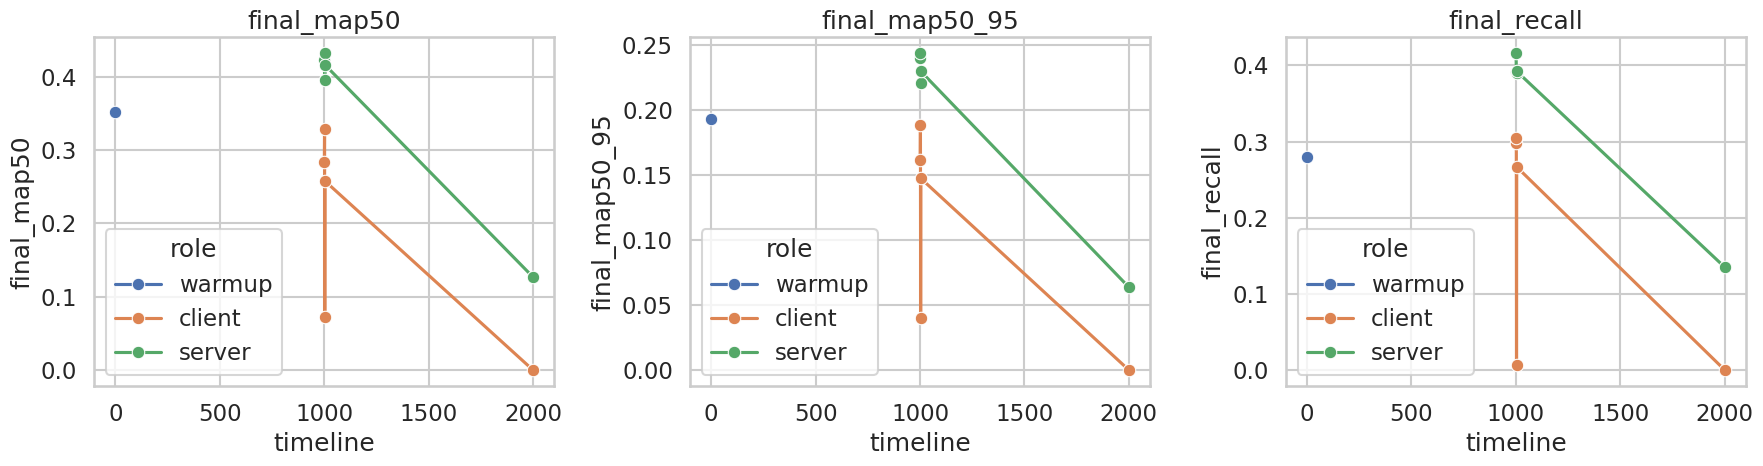

In [3]:
def parse_run_name(run_name: str) -> dict:
    if run_name == "runtime_server_warmup":
        return {"phase": 0, "round": 0, "role": "warmup", "weather": "server_cloudy"}
    match = re.fullmatch(
        r"et_phase(?P<phase>[12])_round(?P<round>\d{3})_(?P<role>server|client\d+_(?P<weather>.+))",
        run_name,
    )
    if not match:
        return {"phase": np.nan, "round": np.nan, "role": "unknown", "weather": ""}
    return {
        "phase": int(match.group("phase")),
        "round": int(match.group("round")),
        "role": "client" if match.group("role").startswith("client") else "server",
        "weather": match.group("weather") or "server_cloudy",
    }


rows = []
for result_path in sorted(RUNS_ROOT.glob("*/results.csv")):
    run_name = result_path.parent.name
    df = pd.read_csv(result_path, skipinitialspace=True).rename(columns=lambda col: col.strip())
    if df.empty:
        continue
    meta = parse_run_name(run_name)
    last = df.iloc[-1].to_dict()
    rows.append(
        {
            "run_name": run_name,
            **meta,
            "epochs_logged": len(df),
            "final_precision": last.get("metrics/precision"),
            "final_recall": last.get("metrics/recall"),
            "final_map50": last.get("metrics/mAP_0.5"),
            "final_map50_95": last.get("metrics/mAP_0.5:0.95"),
            "train_box_loss": last.get("train/box_loss"),
            "train_obj_loss": last.get("train/obj_loss"),
            "train_cls_loss": last.get("train/cls_loss"),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["phase", "round", "role", "run_name"]) if rows else pd.DataFrame()
display(summary_df.round(4) if not summary_df.empty else summary_df)

if not summary_df.empty:
    plot_df = summary_df.copy()
    plot_df["timeline"] = np.where(
        plot_df["phase"] == 0,
        0,
        plot_df["phase"].astype(float) * 1000 + plot_df["round"].astype(float),
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric in zip(axes, ["final_map50", "final_map50_95", "final_recall"]):
        if sns is not None:
            sns.lineplot(data=plot_df, x="timeline", y=metric, hue="role", marker="o", ax=ax)
        else:
            for label, part in plot_df.groupby("role"):
                ax.plot(part["timeline"], part[metric], marker="o", label=label)
            ax.legend()
        ax.set_title(metric)
    plt.tight_layout()
    plt.show()

## 3. Pseudo-Label Snapshot

,phase,round,weather,total_pseudo,active_classes,weighted_confidence,weighted_quality
0,1,1,overcast,121523.0,9,0.2779,0.4874
1,1,2,overcast,141341.0,9,0.5012,0.6406
2,1,3,overcast,143943.0,9,0.5450,0.6687
3,1,4,overcast,81601.0,9,0.5568,0.6868
4,2,1,overcast,117508.0,9,0.4489,0.6119


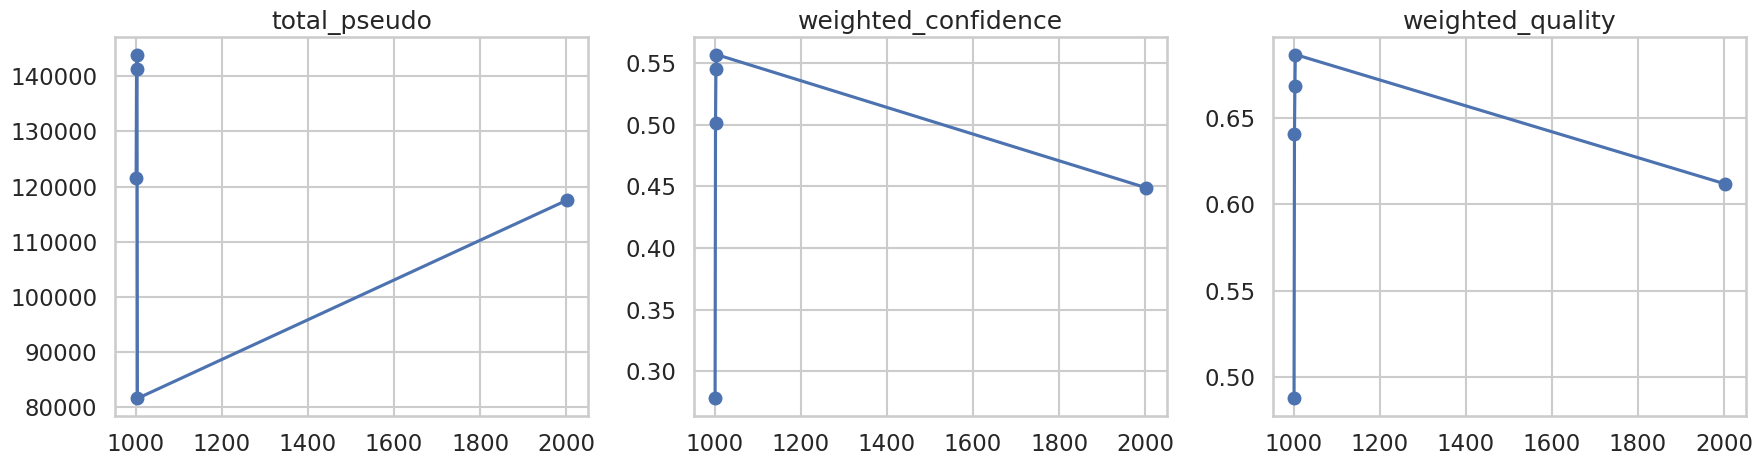

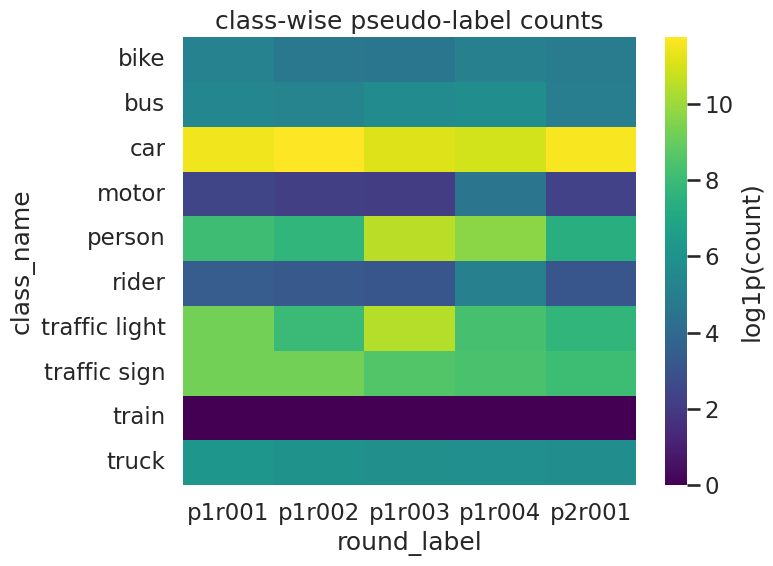

In [4]:
class_names = manifest.get("classes", [str(i) for i in range(10)])
pseudo_rows = []
pseudo_class_rows = []
pattern = re.compile(r"phase(?P<phase>[12])_round(?P<round>\d{3})_client(?P<client>\d+)_(?P<weather>.+)\.json")

for path in sorted(PSEUDO_STATS_ROOT.glob("phase*_round*_client*.json")):
    match = pattern.fullmatch(path.name)
    if not match:
        continue
    payload = json.loads(path.read_text(encoding="utf-8"))
    counts = np.array(payload.get("counts", []), dtype=float)
    mean_conf = np.array(payload.get("mean_confidences", [0] * len(counts)), dtype=float)
    mean_quality = np.array(payload.get("mean_quality_scores", mean_conf), dtype=float)
    total = counts.sum()
    pseudo_rows.append(
        {
            "phase": int(match.group("phase")),
            "round": int(match.group("round")),
            "weather": match.group("weather"),
            "total_pseudo": float(total),
            "active_classes": int((counts > 0).sum()),
            "weighted_confidence": float((counts * mean_conf).sum() / total) if total > 0 else 0.0,
            "weighted_quality": float((counts * mean_quality).sum() / total) if total > 0 else 0.0,
        }
    )
    for class_idx, count in enumerate(counts):
        pseudo_class_rows.append(
            {
                "phase": int(match.group("phase")),
                "round": int(match.group("round")),
                "class_name": class_names[class_idx] if class_idx < len(class_names) else str(class_idx),
                "count": float(count),
            }
        )

pseudo_df = pd.DataFrame(pseudo_rows).sort_values(["phase", "round"]) if pseudo_rows else pd.DataFrame()
pseudo_class_df = pd.DataFrame(pseudo_class_rows)
display(pseudo_df.round(4) if not pseudo_df.empty else pseudo_df)

if not pseudo_df.empty:
    pseudo_df["timeline"] = pseudo_df["phase"] * 1000 + pseudo_df["round"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric in zip(axes, ["total_pseudo", "weighted_confidence", "weighted_quality"]):
        ax.plot(pseudo_df["timeline"], pseudo_df[metric], marker="o")
        ax.set_title(metric)
    plt.tight_layout()
    plt.show()

if not pseudo_class_df.empty:
    pseudo_class_df["round_label"] = (
        "p"
        + pseudo_class_df["phase"].astype(str)
        + "r"
        + pseudo_class_df["round"].astype(str).str.zfill(3)
    )
    pivot = pseudo_class_df.pivot_table(index="class_name", columns="round_label", values="count", aggfunc="sum", fill_value=0)
    plt.figure(figsize=(max(8, 0.8 * len(pivot.columns)), 6))
    if sns is not None:
        sns.heatmap(np.log1p(pivot), cmap="viridis", cbar_kws={"label": "log1p(count)"})
    else:
        plt.imshow(np.log1p(pivot), aspect="auto", cmap="viridis")
        plt.colorbar(label="log1p(count)")
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.title("class-wise pseudo-label counts")
    plt.tight_layout()
    plt.show()

## 4. Paper-Protocol Evaluation

Set `RUN_PAPER_EVAL = True` to evaluate the currently available ET checkpoints only: warmup, the latest phase-1 global, and the latest phase-2 global.

In [5]:
PAPER_EVAL_SPLITS = "cloudy,overcast,rainy,snowy,total"
PAPER_EVAL_BATCH_SIZE = 8
RUN_PAPER_EVAL = False

checkpoint_specs = []
warmup_ckpt = WORK_ROOT / "global_checkpoints" / "round000_warmup.pt"
if warmup_ckpt.exists():
    checkpoint_specs.append(("warmup_global", warmup_ckpt))

phase1_history = [entry for entry in history if int(entry.get("phase", 0)) == 1]
if phase1_history:
    latest_phase1 = phase1_history[-1]
    checkpoint_specs.append((f"phase1_round{int(latest_phase1['round']):03d}_global", Path(latest_phase1["global"])))

phase2_history = [entry for entry in history if int(entry.get("phase", 0)) == 2]
if phase2_history:
    latest_phase2 = phase2_history[-1]
    checkpoint_specs.append((f"phase2_round{int(latest_phase2['round']):03d}_global", Path(latest_phase2["global"])))

eval_cmd = [
    str(PYTHON_BIN),
    str(EVAL_SCRIPT),
    "--workspace",
    str(WORK_ROOT),
    "--splits",
    PAPER_EVAL_SPLITS,
    "--batch-size",
    str(PAPER_EVAL_BATCH_SIZE),
]
for label, path in checkpoint_specs:
    eval_cmd.extend(["--checkpoint", f"{label}={path}"])

print(" ".join(eval_cmd))
if RUN_PAPER_EVAL:
    subprocess.run(eval_cmd, cwd=REPO_ROOT, check=True)
else:
    print("Set RUN_PAPER_EVAL = True to execute the evaluation command above.")

/root/micromamba/envs/al_yolov8/bin/python /app/Object_Detection/efficient_teacher/evaluate_paper_protocol.py --workspace /app/Object_Detection/efficient_teacher/efficientteacher_single_client --splits cloudy,overcast,rainy,snowy,total --batch-size 8 --checkpoint warmup_global=/app/Object_Detection/efficient_teacher/efficientteacher_single_client/global_checkpoints/round000_warmup.pt --checkpoint phase1_round004_global=/app/Object_Detection/efficient_teacher/efficientteacher_single_client/global_checkpoints/phase1_round004_global.pt --checkpoint phase2_round001_global=/app/Object_Detection/efficient_teacher/efficientteacher_single_client/global_checkpoints/phase2_round001_global.pt
Set RUN_PAPER_EVAL = True to execute the evaluation command above.


## 5. Paper-Protocol Results

In [6]:
paper_summary_path = VALIDATION_ROOT / "paper_protocol_eval_summary.csv"
paper_df = pd.read_csv(paper_summary_path) if paper_summary_path.exists() else pd.DataFrame()
display(paper_df.round(4) if not paper_df.empty else paper_df)

ok_rows = paper_df[paper_df["status"].eq("ok")].copy() if not paper_df.empty else pd.DataFrame()
if not ok_rows.empty:
    total_rows = ok_rows[ok_rows["split"].eq("total")].copy()
    display(
        total_rows[["checkpoint_label", "precision", "recall", "map50", "map50_95"]]
        .sort_values("map50", ascending=False)
        .round(4)
    )

    pivot50 = ok_rows.pivot_table(index="split", columns="checkpoint_label", values="map50")
    pivot5095 = ok_rows.pivot_table(index="split", columns="checkpoint_label", values="map50_95")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    if sns is not None:
        sns.heatmap(pivot50, annot=True, fmt=".3f", cmap="Blues", ax=axes[0])
        sns.heatmap(pivot5095, annot=True, fmt=".3f", cmap="Greens", ax=axes[1])
    else:
        axes[0].imshow(pivot50, aspect="auto", cmap="Blues")
        axes[1].imshow(pivot5095, aspect="auto", cmap="Greens")
        axes[0].set_xticks(range(len(pivot50.columns)), pivot50.columns, rotation=90)
        axes[0].set_yticks(range(len(pivot50.index)), pivot50.index)
        axes[1].set_xticks(range(len(pivot5095.columns)), pivot5095.columns, rotation=90)
        axes[1].set_yticks(range(len(pivot5095.index)), pivot5095.index)
    axes[0].set_title("mAP@0.5")
    axes[1].set_title("mAP@0.5:0.95")
    plt.tight_layout()
    plt.show()

""


## 6. Quick Takeaways Table

In [7]:
takeaway_rows = []
if not summary_df.empty:
    server_rows = summary_df[summary_df["role"].isin(["warmup", "server"])].copy()
    if not server_rows.empty:
        latest_server = server_rows.sort_values(["phase", "round"]).iloc[-1]
        takeaway_rows.append(
            {
                "view": "latest_server_training",
                "checkpoint": latest_server["run_name"],
                "map50": latest_server["final_map50"],
                "map50_95": latest_server["final_map50_95"],
                "recall": latest_server["final_recall"],
            }
        )

if not pseudo_df.empty:
    latest_pseudo = pseudo_df.sort_values(["phase", "round"]).iloc[-1]
    takeaway_rows.append(
        {
            "view": "latest_pseudo_stats",
            "checkpoint": f"phase{int(latest_pseudo['phase'])}_round{int(latest_pseudo['round']):03d}",
            "map50": latest_pseudo["total_pseudo"],
            "map50_95": latest_pseudo["weighted_confidence"],
            "recall": latest_pseudo["weighted_quality"],
        }
    )

if not ok_rows.empty:
    best_total = ok_rows[ok_rows["split"].eq("total")].sort_values("map50", ascending=False).iloc[0]
    takeaway_rows.append(
        {
            "view": "best_total_paper_eval",
            "checkpoint": best_total["checkpoint_label"],
            "map50": best_total["map50"],
            "map50_95": best_total["map50_95"],
            "recall": best_total["recall"],
        }
    )

display(pd.DataFrame(takeaway_rows).round(4) if takeaway_rows else pd.DataFrame())

,view,checkpoint,map50,map50_95,recall
0,latest_server_training,et_phase2_round001_server,0.1267,0.0636,0.1350
1,latest_pseudo_stats,phase2_round001,117508.0000,0.4489,0.6119
